# Drucker-Prager Test

This example is adapted from the [OpenSees documentation](https://opensees.github.io/OpenSeesDocumentation).

This model simulates the triaxial compression behavior of a soil-like material
subject to confining pressure and axial loading. The simulation is conducted using
a single 8-node `stdBrick` element with [Drucker–Prager plasticity](https://xara.so/user/manual/material/plastic/DruckerPrager.html). 


## Model

We begin by defining the model builder and creating the nodes of the brick:


In [1]:

import xara
model = xara.Model(ndm=3, ndf=3)

model.node(1, (1.0, 0.0, 0.0))
model.node(2, (1.0, 1.0, 0.0))
model.node(3, (0.0, 1.0, 0.0))
model.node(4, (0.0, 0.0, 0.0))
model.node(5, (1.0, 0.0, 1.0))
model.node(6, (1.0, 1.0, 1.0))
model.node(7, (0.0, 1.0, 1.0))
model.node(8, (0.0, 0.0, 1.0))



The boundary conditions are applied to simulate triaxial constraints, fixing displacements appropriately on different node sets:

In [2]:
model.fix( 1, (0, 1, 1))
model.fix( 2, (0, 0, 1))
model.fix( 3, (1, 0, 1))
model.fix( 4, (1, 1, 1))
model.fix( 5, (0, 1, 0))
model.fix( 6, (0, 0, 0))
model.fix( 7, (1, 0, 0))
model.fix( 8, (1, 1, 0));

The Drucker–Prager material is defined with specified parameters for elasticity, yield surface, and hardening behavior:



In [3]:

material = xara.MultiaxialMaterial("DruckerPrager", 
    K       = 27777.78 , # bulk modulus
    G       =  9259.26 , # shear modulus
    Fy      =     5.0  , # yield stress
    Rvol    =     0.398,
    Rbar    =     0.398,
    Fs      =     0.0  ,
    Fo      =     0.0  ,
    Hsat    =     0.0  ,
    H       =     0.0  ,
    theta   =     1.0  ,
    delta2  =     0.0  ,
    density =     1.7
)
model.material(material)



The model includes a single `stdBrick` element to represent the soil specimen:


In [4]:

model.element("stdBrick", 1, (1, 2, 3, 4, 5, 6, 7, 8), material, 0.0, 0.0, 0.0)


1


## Recorders

Nodal displacements and Gauss point quantities such as stress, strain, and material state variables are recorded:


In [5]:
step = 0.1

model.recorder("Node", "disp", file="out/displacements1.out", time=True, dT=step, nodeRange=(1, 8), dof=(1, 2, 3))

model.recorder("Element", "material", 2, "stress", element=1, time=True, file="out/stress1.out", dT=step)
model.recorder("Element", "material", 2, "strain", element=1, time=True, file="out/strain1.out", dT=step)
model.recorder("Element", "material", 2, "state" , element=1, time=True, file="out/state1.out",  dT=step)

3


## Loading

Two loading patterns are defined: the first applies hydrostatic pressure, and the second imposes axial deviatoric stress:

In [6]:

p = 10.0
pNode = -p * 0.25


p1 = xara.StaticPattern(
    series=xara.TimeSeries(time=[0, 10, 100], values=[0, 1, 1]),
    loads=xara.NodalLoad(model, {
        1:  (pNode,   0.0, 0.0),
        2:  (pNode, pNode, 0.0),
        3:  (  0.0, pNode, 0.0),
        5:  (pNode,   0.0, 0.0),
        6:  (pNode, pNode, 0.0),
        7:  (  0.0, pNode, 0.0),
    })
)
model.pattern(p1)

p2 = xara.StaticPattern(
    series=xara.TimeSeries(time=[0, 10, 100], values=[0, 1, 5]),
    loads=xara.NodalLoad(model, {
        5:  (0.0, 0.0, pNode),
        6:  (0.0, 0.0, pNode),
        7:  (0.0, 0.0, pNode),
        8:  (0.0, 0.0, pNode),
    })
)
model.pattern(p2)


## Analysis



In [ ]:
analysis = xara.StaticAnalysis(model, 
                               integrator=("LoadControl", 0.1),
                               constraints="Transformation",
                               system="SparseGeneral",
                               test=("NormDispIncr", 1e-5, 1, 9))

analysis.analyze(963)
model.wipe()

The displacements over time are recovered from the recorders and plotted as follows:


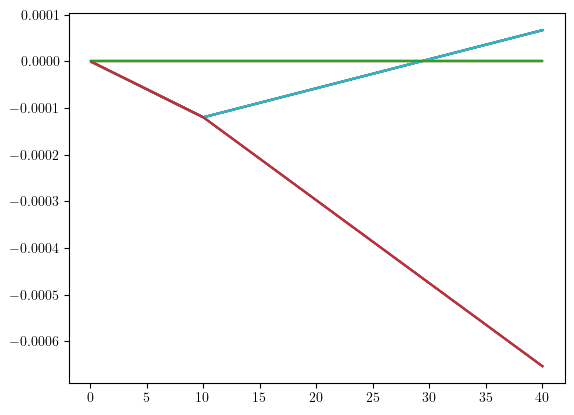

In [8]:
import matplotlib.pyplot as plt
import numpy as np


t, *U = np.loadtxt("out/displacements1.out").T
n = 400
for u in U:
    plt.plot(t[:n], u[:n])
